# ISO 20414:2020 — Test 7: Overtaking People with Movement Disabilities

Two 4 m x 5 m rooms joined by a 12 m x 1,5 m ramp with **`speed_factor = 0.5`  (ISO 20414:2020 Table 8). Room 1 has two zones. 24 occupants of Zone 1 is moving to the exit in room 2. In Zone 2, there is a disabled occupant occupying a bigger area (e.g. a wheelchair user) also moving to the exit with a considerably slower speed. The scenario is repeated with an occupant in Zone 2 who has the same charasterics as others (i.e. no disabled occupant is simulated). The expected result is that occupants in zone 1 in the first scenario reach the exit in a time slower than the occupants in repeated scenario.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 05 August 2026, 16:43 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and Run the Scenario 1

In [4]:
SCENARIO_ZIP_1 = Path("scenario_files") / "Iso-07-movement-disabilities.zip"
scenario_1 = load_scenario(str(SCENARIO_ZIP_1))
print(scenario_1.summary())
result_1 = run_scenario(scenario_1, seed=42)
walkable_1 = scenario_1.walkable_polygon
df1 = result_1.trajectory_dataframe()

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/iso/scenario_files/Iso-07-movement-disabilities.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 2
  Stages:        0
  Zones:         1
  Journeys:      0
  Agents:        ~25
    jps-distributions_0: 24 agents
    jps-distributions_1: 1 agents


## Load and Run the Scenario 2

In [5]:
SCENARIO_ZIP_2 = Path("scenario_files") / "Iso-07-movement-disabilities-no-disability.zip"
scenario_2 = load_scenario(str(SCENARIO_ZIP_2))
print(scenario_2.summary())
result_2 = run_scenario(scenario_2, seed=42)
walkable_2 = scenario_2.walkable_polygon
df2 = result_2.trajectory_dataframe()

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/iso/scenario_files/Iso-07-movement-disabilities-no-disability.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 2
  Stages:        0
  Zones:         1
  Journeys:      0
  Agents:        ~25
    jps-distributions_0: 24 agents
    jps-distributions_1: 1 agents


In [6]:
def agent_ids_by_start_zone(df, scenario):
    first_positions = (
        df.sort_values(["id", "frame"])
        .groupby("id", as_index=False)
        .first()
    )

    distributions = {
        name: Polygon(data["coordinates"])
        for name, data in scenario.raw["distributions"].items()
    }

    ids_by_zone = {name: set() for name in distributions}

    for row in first_positions.itertuples():
        start = Point(row.x, row.y)
        for name, polygon in distributions.items():
            if polygon.covers(start):
                ids_by_zone[name].add(row.id)
                break

    return ids_by_zone


zones_1 = agent_ids_by_start_zone(df1, scenario_1)
zones_2 = agent_ids_by_start_zone(df2, scenario_2)

zone1_ids_s1 = zones_1["jps-distributions_0"]
zone2_ids_s1 = zones_1["jps-distributions_1"]

zone1_ids_s2 = zones_2["jps-distributions_0"]
zone2_ids_s2 = zones_2["jps-distributions_1"]
def evacuation_times_by_agent(df, frame_rate):
    times = (
        df.groupby("id")["frame"]
        .max()
        .div(frame_rate)
        .rename("evacuation_time_s")
    )
    return times


agent_times_1 = evacuation_times_by_agent(df1, result_1.frame_rate)
agent_times_2 = evacuation_times_by_agent(df2, result_2.frame_rate)

zone1_evacuation_1 = agent_times_1.loc[list(zone1_ids_s1)].max()
zone1_evacuation_2 = agent_times_2.loc[list(zone1_ids_s2)].max()

In [7]:
comparison = pd.DataFrame(
    {
        "Scenario": [
            "Scenario 1 — movement disability",
            "Scenario 2 — no disability",
        ],
        "Total Evacuation Time (s)": [
            result_1.evacuation_time,
            result_2.evacuation_time,
        ],
    }
)
display(comparison.round(2))

,Scenario,Total Evacuation Time (s)
0,Scenario 1 — movement disability,50.21
1,Scenario 2 — no disability,41.37


## Plot Trajectories

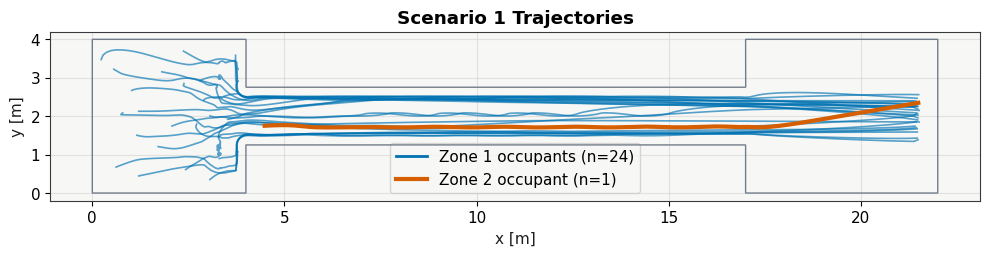

In [8]:
# Plot Scenario 1 trajectories, colored by starting zone
fig, ax = plt.subplots(figsize=(12, 5))

walkable_area = pedpy.WalkableArea(walkable_1)
pedpy.plot_walkable_area(walkable_area=walkable_area, axes=ax)

for agent_id, trajectory in (
    df1.sort_values(["id", "frame"]).groupby("id")
):
    if agent_id in zone2_ids_s1:
        color = "#D55E00"
        linewidth = 3.0
        alpha = 1.0
        zorder = 3
    else:
        color = "#0072B2"
        linewidth = 1.2
        alpha = 0.65
        zorder = 2

    ax.plot(
        trajectory["x"],
        trajectory["y"],
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder,
    )

# Legend handles
ax.plot(
    [], [],
    color="#0072B2",
    linewidth=2,
    label=f"Zone 1 occupants (n={len(zone1_ids_s1)})",
)
ax.plot(
    [], [],
    color="#D55E00",
    linewidth=3,
    label=f"Zone 2 occupant (n={len(zone2_ids_s1)})",
)

ax.set_title("Scenario 1 Trajectories")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

## Acceptance

In [9]:
assert result_1.evacuation_time > result_2.evacuation_time, (
    f"Expected Scenario 1 evacuation time ({result_1.evacuation_time:.2f} s) "
    f"to be greater than Scenario 2 ({result_2.evacuation_time:.2f} s)."
)
result_1.cleanup()
result_2.cleanup();